In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import jax.numpy as jnp
import numpy as np
import arviz as az
import healpy as hp

sys.path.append("../..")
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../notebooks/matplotlibrc")

In [2]:
from common import *

In [3]:
z = np.load("iso/counts_10.npy")

In [5]:
np.mean(z)

1.355644

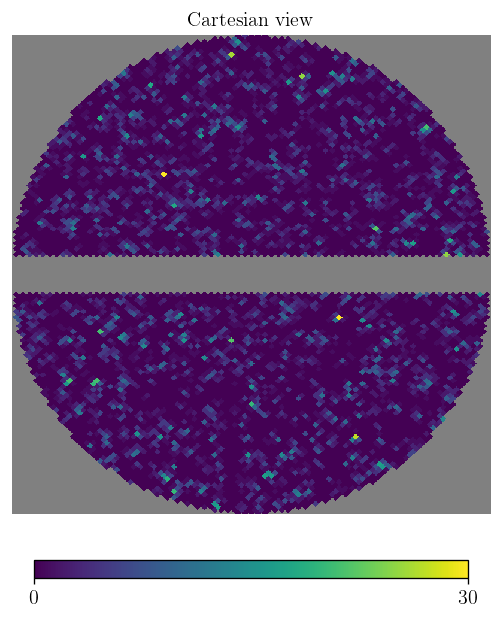

In [4]:
z_plot = np.zeros(hp.nside2npix(128))
z_plot[~mask_plane] = z
z_plot[mask_plane] = hp.UNSEEN
hp.cartview(z_plot, latra=[-25,25],lonra=[-25,25])

## 1. Posteriors

In [14]:
samples_dict = {str(i) : pickle.load(open(f"unmasked/hmc_samples_{i}.p", "rb")) for i in range(4)}

In [15]:
valid_i_s = samples_dict.keys()
colors_dict = {i_str: cms['viridis'](float(i_str)/(len(samples_dict)-1)) for i_str in valid_i_s}
labels_dict = {i_str: i_str for i_str in valid_i_s}
print(samples_dict['0'].keys())

dict_keys(['C', 'Sps_dsk', 'zs'])


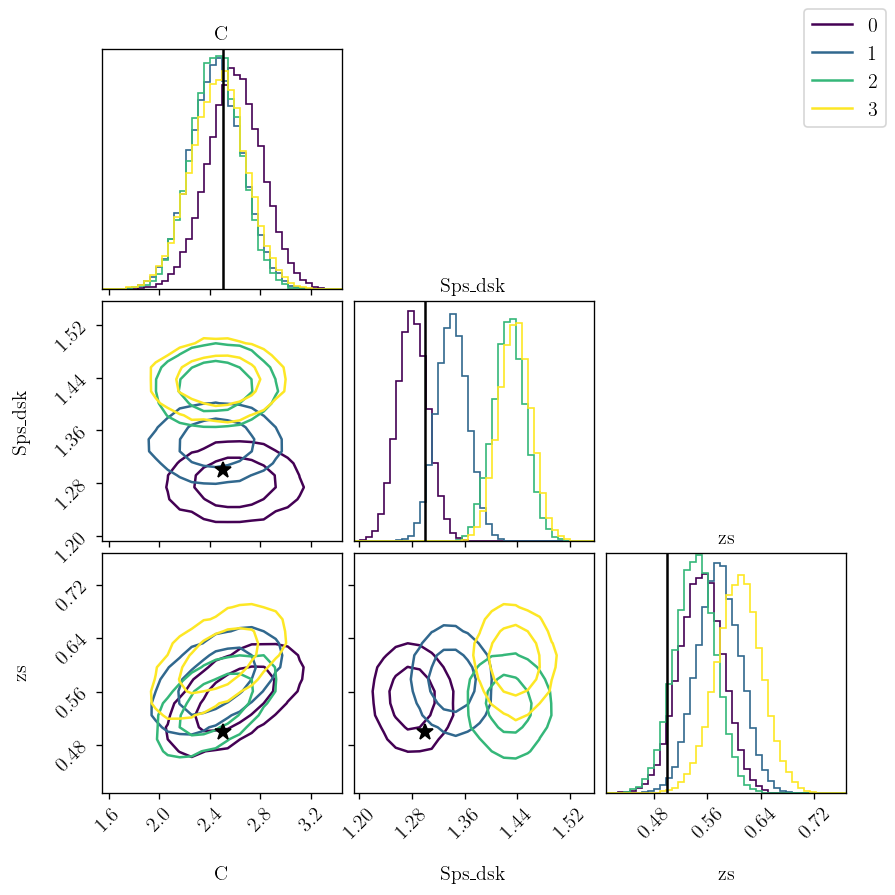

In [16]:
# plot_var_names = [
#     'Sps_dsk', 'Sps_gce', 'gamma_ps', 'zs', 'C'
# ]
plot_var_names = list(samples_dict['0'].keys())
#logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    colors_dict=colors_dict, labels_dict=labels_dict,
    point_est=truth_dict,
    hist_bin_factor=2, save_fn=None
)

## 1.1 Likelihood

In [20]:
sys.path.append("../..")
from models.scd import dnds
from likelihoods.npll_jax import log_like_np

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def ll(data=..., k_max=..., npixROI=..., zs=..., C=..., Sps_dsk=...):
    # data is unmasked

    # general setting
    nm = mask_plane
    m = mask_plane
    data_in = data[~m]

    # poisson
    mu = jnp.zeros_like(data)[~m]

    # disk: param
    temp_dsk = disk_template.get_template(zs=zs, C=C)

    # disk: normalization
    A_dsk = 1 / jnp.mean(temp_dsk[~nm])
    temp_dsk = A_dsk * temp_dsk
    npt_compressed = jnp.array([temp_dsk])

    # disk: scd
    theta = []
    vd = truth_dict
    for ips, ps in enumerate(["dsk"]):

        n1 = vd['n1_dsk']
        n2 = vd['n2_dsk']
        n3 = vd['n3_dsk']
        sb1 = vd['sb1_dsk']
        lambda_s = vd['lambdas_dsk']

        theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
        s_ary = jnp.logspace(-1., 2., 100)
        dnds_ary = dnds(s_ary, theta_tmp)
        A = Sps_dsk / jnp.mean(npt_compressed[ips][~nm] * jnp.trapz(s_ary * dnds_ary, s_ary))
        theta.append([A, n1, n2, n3, sb1, lambda_s * sb1])
    theta = jnp.array(theta)

    npt_compressed_in = jnp.array([temp_dsk[~m]])
    
    return log_like_np(theta, mu, npt_compressed_in, data_in, f_ary, df_rho_div_f_ary, k_max, npixROI)

In [64]:
counts = np.load("unmasked/counts_0.npy")

data_in = np.zeros(hp.nside2npix(nside), dtype=np.int32)
data_in[~mask_plane] = counts
data_in = jnp.asarray(data_in, dtype=jnp.int32)
k_max = int(np.max(data_in))
npixROI = int(np.sum(~mask_plane))

In [65]:
Sps_arr = np.linspace(1.2, 1.5, 30)
zs_arr = np.linspace(0.4, 0.8, 30)

ll_ss = []
for Sps in tqdm(Sps_arr):
    ll_s = []
    for zs in zs_arr:
        ll_s.append(ll(data=data_in, k_max=k_max, npixROI=npixROI, zs=zs, C=2.5, Sps_dsk=Sps))
    ll_ss.append(ll_s)
ll_ss = np.sum(ll_ss, axis=-1)

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:11<00:00,  2.61it/s]


In [66]:
hmc_samples = pickle.load(open("unmasked/hmc_samples_0.p", "rb"))

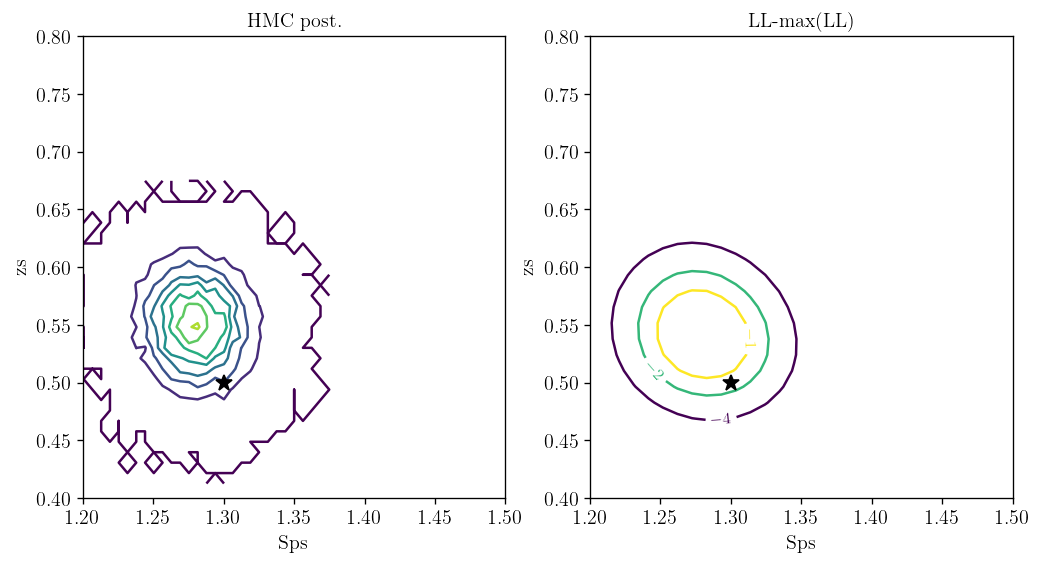

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
h, xe, ye = np.histogram2d(hmc_samples['Sps_dsk'], hmc_samples['zs'], bins=30, density=True)
x = (xe[1:] + xe[:-1])/2
y = (ye[1:] + ye[:-1])/2
ax.contour(x, y, h.T, cmap='viridis')
ax.plot(truth_dict['Sps_dsk'], truth_dict['zs'], '*', color='k', ms=10)
ax.set(xlim=(1.2, 1.5), ylim=(0.4, 0.8), xlabel="Sps", ylabel="zs", title='HMC post.')

ax = axs[1]
ct = ax.contour(Sps_arr, zs_arr, ll_ss.T-np.max(ll_ss), levels=[-4, -2, -1])
ax.clabel(ct, inline=True, fontsize=10)
ax.plot(truth_dict['Sps_dsk'], truth_dict['zs'], '*', color='k', ms=10)
ax.set(xlabel="Sps", ylabel="zs", title='LL-max(LL)');

## 2. Coverage

In [50]:
roc_runs = {k : [] for k in truth_dict.keys()}
for ks, samples in tqdm(samples_dict.items()):
    for k in samples.keys():
        v = truth_dict[k]
        # if k in ['zs', 'C', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk']:
        #     continue
        samples_k = np.array(samples[k])
        roc_runs[k].append(find_hdi_prob(samples_k, v, level=15))
for k in roc_runs.keys():
    roc_runs[k] = np.sort(roc_runs[k])

print(list(samples.keys()))

100%|██████████| 30/30 [00:00<00:00, 186.75it/s]

['C', 'Sps_dsk', 'zs']


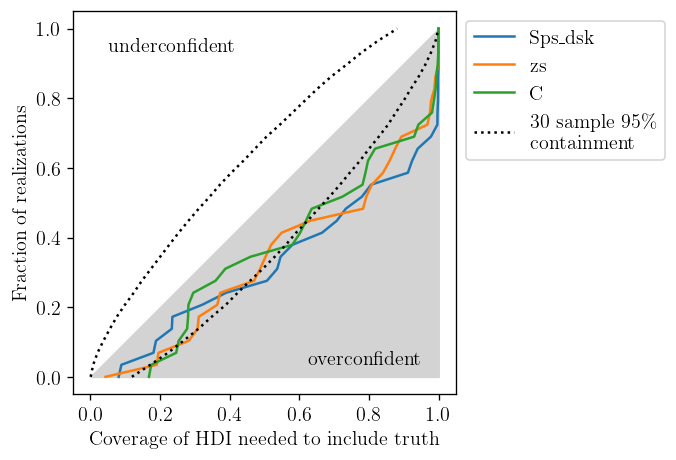

In [51]:
n_run = len(samples_dict)
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)

fig, ax = plt.subplots()

view_keys = list(samples.keys())

linestyles = ['-', '--', ':', '-.']

ax.fill_between([0,1], [0,1], color='lightgray')
for i, (k, roc) in enumerate(roc_runs.items()):
    if k in view_keys:
        ax.plot(roc, np.linspace(0, 1, n_run), label=k, color=f'C{i%10}', linestyle=linestyles[i//10])

ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations')
ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout();

## 3. Check normalization

In [10]:
counts = [np.load(f'gaus_1e-3/counts_{i}.npy') for i in range(100)]
means = [np.mean(c) for c in counts]
means2 = []
for c in counts:
    z = np.zeros(hp.nside2npix(nside))
    z[~mask_plane] = c
    means2.append(np.mean(z[~mask_roi]))

1.2970684 0.003870994225144386


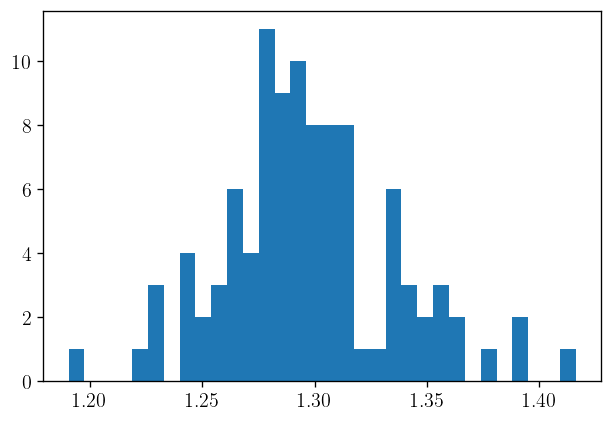

In [11]:
plt.hist(means, bins=32);
print(np.mean(means), np.std(means) / np.sqrt(100))

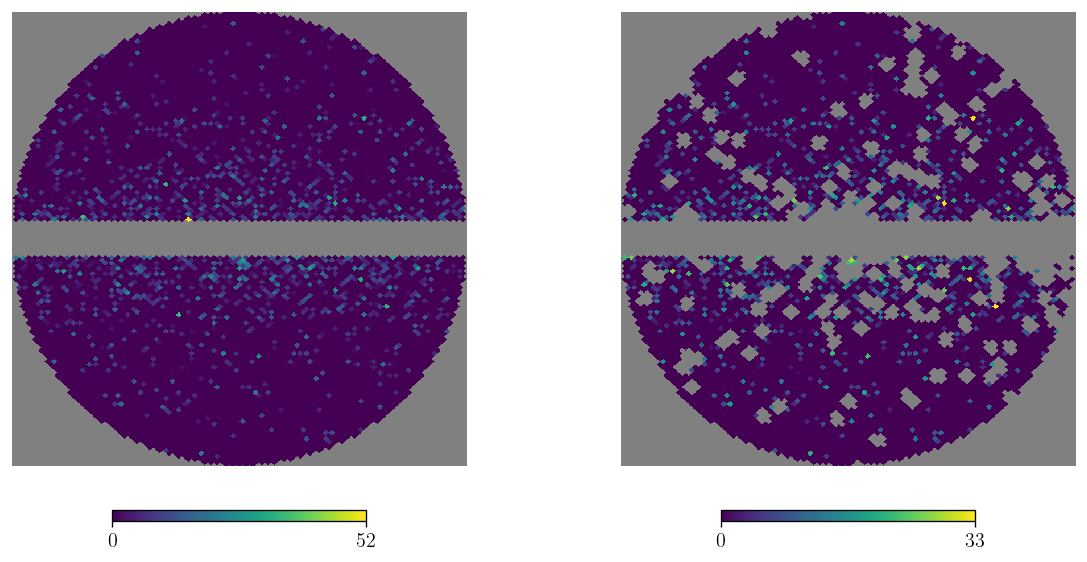

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

z = np.zeros(hp.nside2npix(nside))
z[~mask_plane] = counts[0]
z[mask_plane] = hp.UNSEEN

plt.sca(axs[0])
hp.cartview(z, latra=[-25, 25], lonra=[-25, 25], hold=True, title='')

z = np.zeros(hp.nside2npix(nside))
z[~mask_plane] = counts[0]
z[mask_roi] = hp.UNSEEN

plt.sca(axs[1])
hp.cartview(z, latra=[-25, 25], lonra=[-25, 25], hold=True, title='')

## 4. psf

In [3]:
kp = KingPSF()
psf_r_func = kp.psf_fermi_r
f_ary, df_rho_div_f_ary = psf_corr(psf_r_func=psf_r_func, num_f_bins=30)

sigma = np.deg2rad(0.001) / 3
psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
f_ary_delta, df_rho_div_f_ary_delta = psf_corr(psf_r_func=psf_r_func, num_f_bins=30)

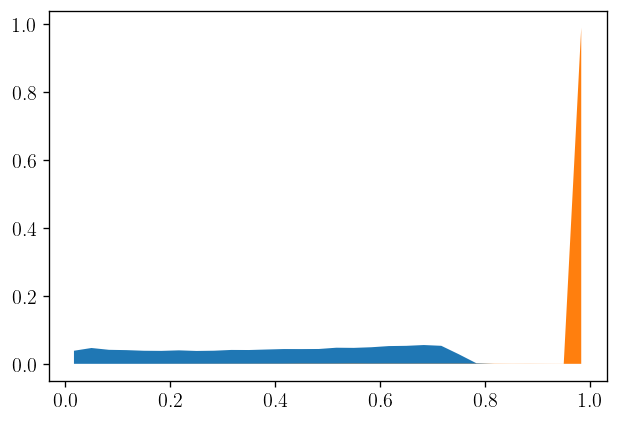

In [6]:
plt.fill_between(f_ary, f_ary**2*df_rho_div_f_ary)
plt.fill_between(f_ary_delta, f_ary_delta**2*df_rho_div_f_ary_delta)

In [7]:
np.sum(f_ary_delta**2*df_rho_div_f_ary_delta)

1.0